<a href="https://colab.research.google.com/github/Saifullah785/machine-learning-engineer-roadmap/blob/main/Lecture_77_imbalanced_data_yt/Lecture_77_imbalanced_data_yt.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# importing the necessary libraries
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
import numpy as np
import xgboost as xgb
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from sklearn.metrics import classification_report, roc_auc_score, roc_curve
from sklearn.model_selection import train_test_split

In [ ]:
# set random seed for reproducibility
np.random.seed(42)


In [ ]:
# Generate imbalanced dataset
n_samples_1 = 25
n_samples_2 = 375
center = [(0,0), (2,2)]
cluster_std = [1.5,1.5]

In [ ]:
# Generate the imbalanced dataset
X, y = make_blobs(n_samples=[n_samples_1, n_samples_2], centers=center, cluster_std=cluster_std, random_state=0)

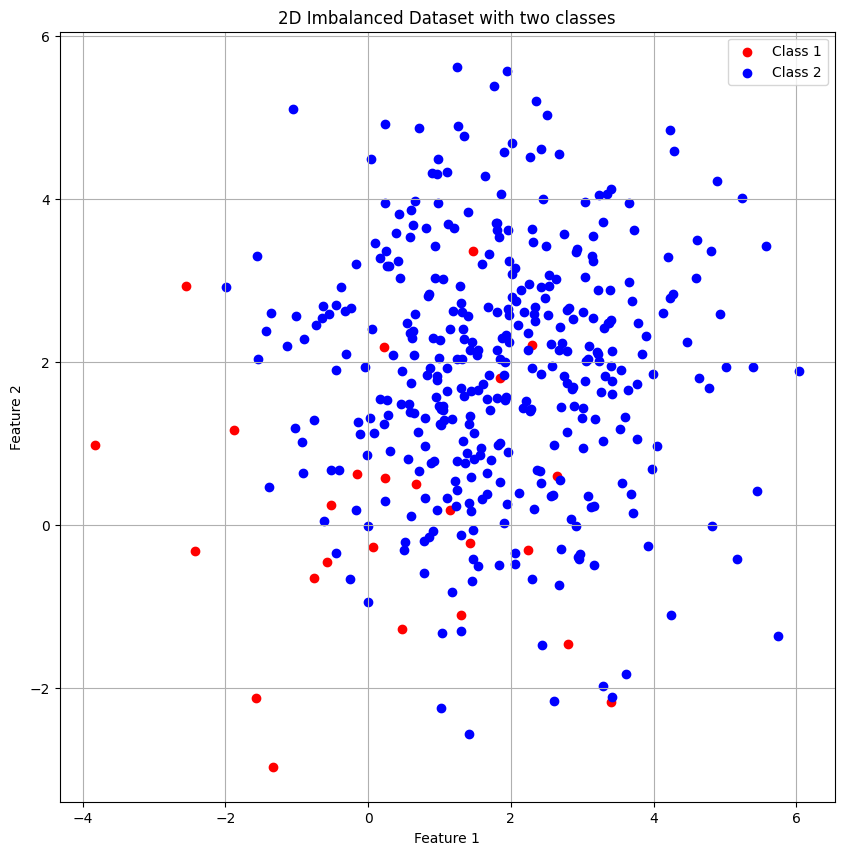

In [ ]:
# plotting
plt.figure(figsize=(10,10))
plt.scatter(X[y == 0][:, 0],X[y == 0][:,1], color='red', label='Class 1')
plt.scatter(X[y == 1][:, 0],X[y == 1][:,1], color='blue', label='Class 2')
plt.title('2D Imbalanced Dataset with two classes')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
# Import additional machine learning libraries
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, roc_auc_score, roc_curve
from sklearn.model_selection import train_test_split

In [ ]:
# Split dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [ ]:
# Initialize and train a Logistic Regression classifier
classifier = LogisticRegression()
classifier.fit(X_train, y_train)

LogisticRegression()

In [ ]:
# predict test set
y_pred = classifier.predict(X_test)
y_proba = classifier.predict_proba(X_test)[:, 1]

In [ ]:
# Print classification report
print('Classification Report:')
print(classification_report(y_test, y_pred))

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.29      0.44         7
           1       0.96      1.00      0.98       113

    accuracy                           0.96       120
   macro avg       0.98      0.64      0.71       120
weighted avg       0.96      0.96      0.95       120



In [ ]:
# print ROC AUC Score
print('ROC AUC Score:', roc_auc_score(y_test, y_proba))

ROC AUC Score: 0.9557522123893806


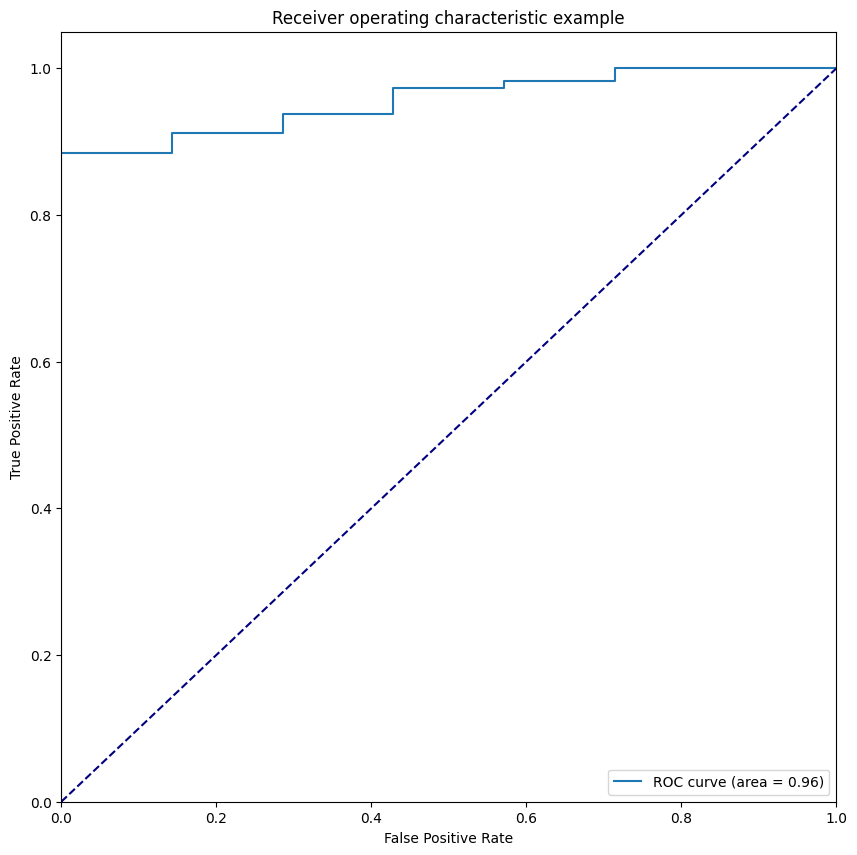

In [ ]:
# plotting ROC AUC Curve
fpr, tpr, _ = roc_curve(y_test, y_proba)
plt.figure(figsize=(10,10))
plt.plot(fpr, tpr, label= 'ROC curve (area = %0.2f)' % roc_auc_score(y_test, y_proba))
plt.plot([0, 1], [0, 1], color='navy', linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver operating characteristic example')
plt.legend(loc="lower right")
plt.show()

In [ ]:
# Function to plot decision boundaries
def plot_decision_boundary(X, y, model):
  plot_step = 0.02
  x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
  y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
  xx, yy = np.meshgrid(np.arange(x_min, x_max, plot_step), np.arange(y_min, y_max, plot_step))
  Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
  Z = Z.reshape(xx.shape)
  plt.contourf(xx, yy, Z, alpha=0.3)
  plt.scatter(X[:, 0], X[:, 1], c=y, edgecolors='k', s =20)
  plt.title('Decision Boundary')
  plt.show()


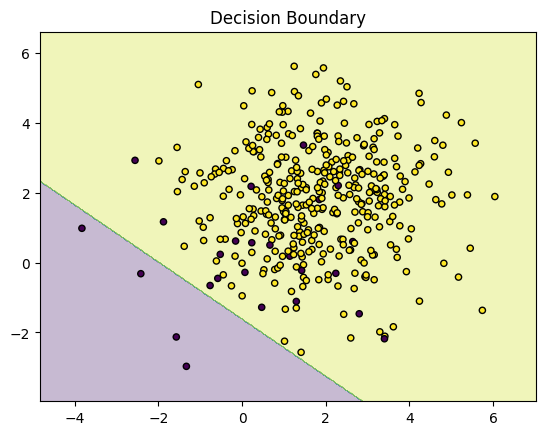

In [ ]:
# plot decision boundary
plot_decision_boundary(X, y, classifier)

# Random Undersampling

In [ ]:
# Import RandomUnderSampler for undersampling
from imblearn.under_sampling import RandomUnderSampler

In [ ]:
# split dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
# Applying Random Undersampling to balance the dataset
rus = RandomUnderSampler(random_state=42)
X_resampled, y_resampled = rus.fit_resample(X_train, y_train)

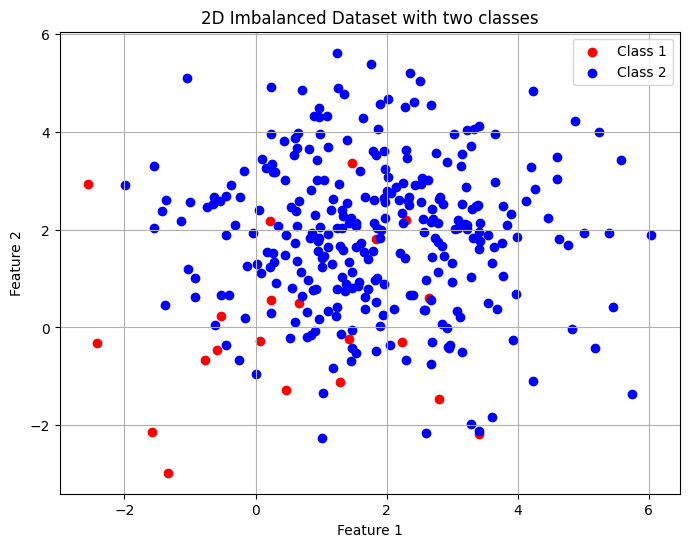

In [ ]:
# Plotting
plt.figure(figsize=(8, 6))
plt.scatter(X_train[y_train == 0][:, 0], X_train[y_train == 0][:, 1],color='red', label='Class 1')
plt.scatter(X_train[y_train == 1][:, 0], X_train[y_train == 1][:, 1], color='blue', label='Class 2')
plt.title('2D Imbalanced Dataset with two classes')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.legend()
plt.grid(True)
plt.show()

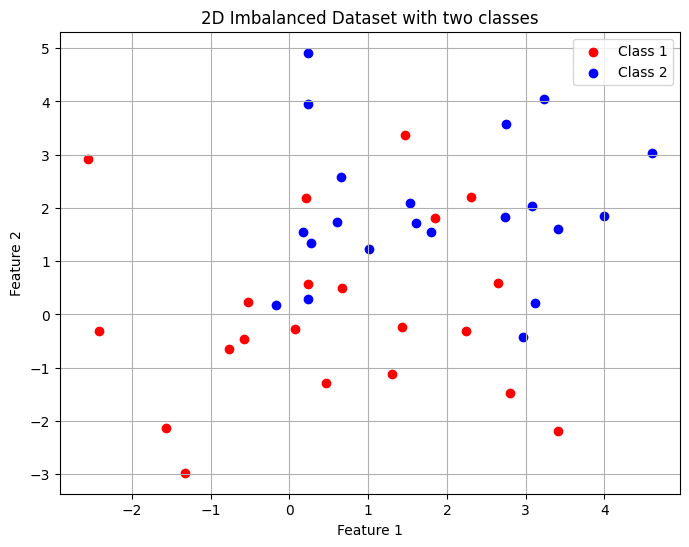

In [ ]:
# plotting
plt.figure(figsize=(8, 6))
plt.scatter(X_resampled[y_resampled == 0][:, 0], X_resampled[y_resampled == 0][:, 1], color='red', label='Class 1')
plt.scatter(X_resampled[y_resampled == 1][:, 0], X_resampled[y_resampled == 1][:, 1], color='blue', label='Class 2')
plt.title('2D Imbalanced Dataset with two classes')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
# Display the shape of the original training data
X_train.shape

(320, 2)

In [ ]:
# Display the shape of the resampled training data
X_resampled.shape

(42, 2)

In [ ]:
# Count the occurrences of each class in the original training set
import pandas as pd

pd.Series(y_train).value_counts()

,count
1,299
0,21


In [ ]:
# Count the occurrences of each class in the resampled training set
pd.Series(y_resampled).value_counts()

,count
0,21
1,21


In [ ]:
# Initialize and train a Logistic Regression classifier on the undersampled data
from sklearn.linear_model import LogisticRegression

classifier_rus = LogisticRegression()
classifier_rus.fit(X_resampled, y_resampled)

LogisticRegression()

In [ ]:
# Predict test set

y_pred_rus = classifier_rus.predict(X_test)
y_proba_rus = classifier_rus.predict_proba(X_test)[:, 1]

In [ ]:
# Print classification report for undersampled data

print('Classification Report (with Over Sampling):')
print(classification_report(y_test, y_pred_rus))

Classification Report (with Over Sampling):
              precision    recall  f1-score   support

           0       0.18      1.00      0.31         4
           1       1.00      0.76      0.87        76

    accuracy                           0.78        80
   macro avg       0.59      0.88      0.59        80
weighted avg       0.96      0.78      0.84        80



In [ ]:
# Print ROC AUC Score for undersampled data
print('ROC AUC Score (with Over Sampling):', roc_auc_score(y_test, y_proba_rus))

ROC AUC Score (with Over Sampling): 0.9375


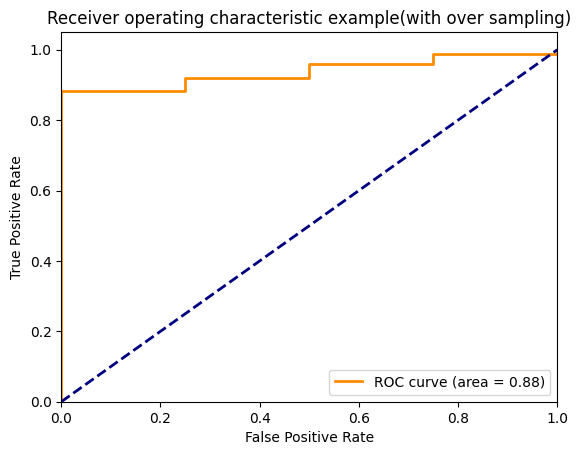

In [ ]:
# Plotting ROC AUC Curve for resampled data
fpr_rus, tpr_rus, _ = roc_curve(y_test, y_proba_rus)
plt.figure()
plt.plot(fpr_rus, tpr_rus, color='darkorange', lw=2, label= 'ROC curve (area = %0.2f)' % roc_auc_score(y_test, y_pred_rus))

plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver operating characteristic example(with over sampling)')
plt.legend(loc="lower right")
plt.show()

In [ ]:
# Function to plot decision boundaries for undersampled data
def plot_decision_boundaries_ros(X, y, model):
  plot_step = 0.02
  x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
  y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
  xx, yy = np.meshgrid(np.arange(x_min, x_max, plot_step), np.arange(y_min, y_max, plot_step))
  Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
  Z = Z.reshape(xx.shape)
  plt.contourf(xx, yy, Z, alpha=0.3)
  plt.scatter(X[:, 0], X[:, 1], c=y, edgecolors='k', s =20)
  plt.title('Decision Boundary (with Over Sampling)')
  plt.show()

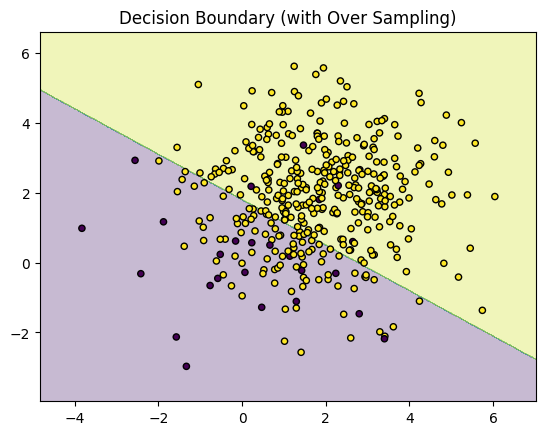

In [ ]:
# plot decision boundary for resampled data
plot_decision_boundaries_ros(X, y, classifier_rus)

## SMOTE

In [ ]:
# Import SMOTE for oversampling
from imblearn.over_sampling import SMOTE

In [ ]:
# split dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
# Applying SMOTE
smote = SMOTE(random_state=42)
X_resampled_smote, y_resampled_smote = smote.fit_resample(X_train, y_train)


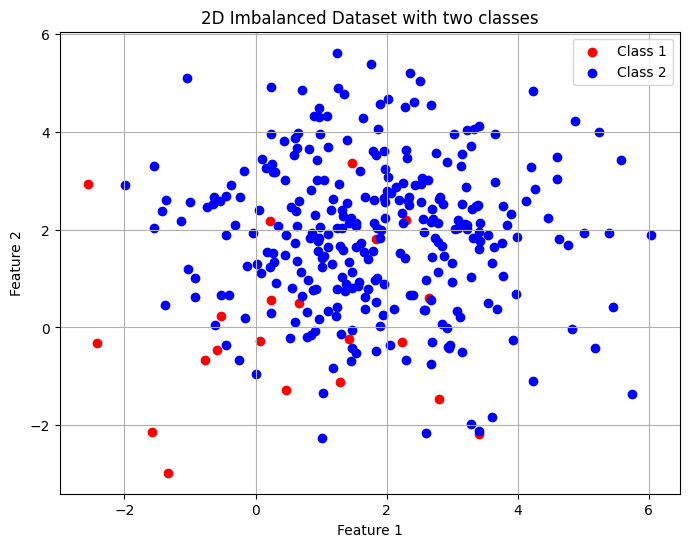

In [ ]:
# Plotting
plt.figure(figsize=(8, 6))
plt.scatter(X_train[y_train == 0][:, 0], X_train[y_train == 0][:, 1],color='red', label='Class 1')
plt.scatter(X_train[y_train == 1][:, 0], X_train[y_train == 1][:, 1], color='blue', label='Class 2')
plt.title('2D Imbalanced Dataset with two classes')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.legend()
plt.grid(True)
plt.show()

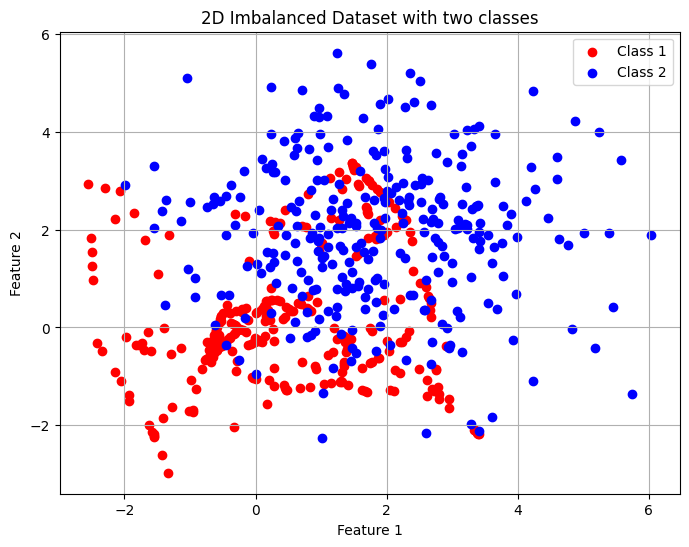

In [ ]:
# plotting
plt.figure(figsize=(8, 6))
plt.scatter(X_resampled_smote[y_resampled_smote == 0][:, 0], X_resampled_smote[y_resampled_smote == 0][:, 1], color='red', label='Class 1')
plt.scatter(X_resampled_smote[y_resampled_smote == 1][:, 0], X_resampled_smote[y_resampled_smote == 1][:, 1], color='blue', label='Class 2')
plt.title('2D Imbalanced Dataset with two classes')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
# Display the shape of the original training data
X_train.shape

(320, 2)

In [ ]:
# Display the shape of the SMOTE resampled training data
X_resampled_smote.shape

(598, 2)

In [ ]:
# Count the occurrences of each class in the original training set
pd.Series(y_train).value_counts()

,count
1,299
0,21


In [ ]:
# Count the occurrences of each class in the SMOTE resampled training set
pd.Series(y_resampled_smote).value_counts()

,count
1,299
0,299


In [ ]:
# Initialize and train a Logistic Regression classifier on the SMOTE resampled data
classifier_smote = LogisticRegression()
classifier_smote.fit(X_resampled_smote, y_resampled_smote)

LogisticRegression()

In [ ]:
# predict test set
y_pred_smote = classifier_smote.predict(X_test)
y_proba_smote = classifier_smote.predict_proba(X_test)[:, 1]


In [ ]:
# print classification report for SMOTE data
print('Classification Report (with SMOTE):')
print(classification_report(y_test, y_pred_smote))

Classification Report (with SMOTE):
              precision    recall  f1-score   support

           0       0.17      1.00      0.30         4
           1       1.00      0.75      0.86        76

    accuracy                           0.76        80
   macro avg       0.59      0.88      0.58        80
weighted avg       0.96      0.76      0.83        80



In [ ]:
# print ROC AUC Score for SMOTE data
print('ROC AUC Score (with SMOTE):', roc_auc_score(y_test, y_proba_smote))

ROC AUC Score (with SMOTE): 0.950657894736842


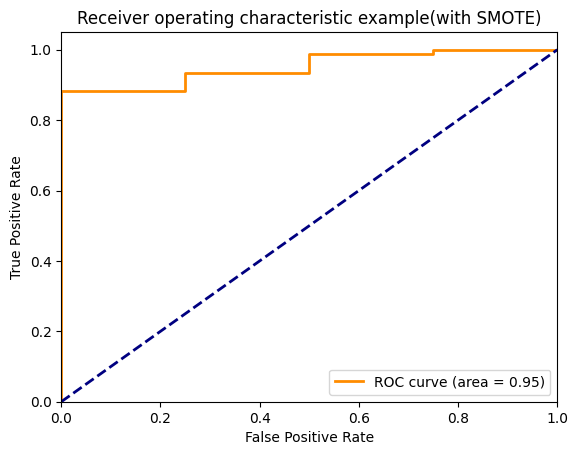

In [ ]:
# plotting ROC AUC Curve for SMOTE data
fpr_smote, tpr_smote, _ = roc_curve(y_test, y_proba_smote)
plt.figure()
plt.plot(fpr_smote, tpr_smote, color='darkorange', lw=2, label= 'ROC curve (area = %0.2f)' % roc_auc_score(y_test, y_proba_smote))

plt.plot([0,1], [0,1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver operating characteristic example(with SMOTE)')
plt.legend(loc="lower right")
plt.show()

In [ ]:
# Function to plot decision boundaries for SMOTE data
def plot_decision_boundaries_smote(X, y, model):
  plot_step = 0.02
  x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
  y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
  xx, yy = np.meshgrid(np.arange(x_min, x_max, plot_step), np.arange(y_min, y_max, plot_step))
  Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
  Z = Z.reshape(xx.shape)
  plt.contourf(xx, yy, Z, alpha=0.3)
  plt.scatter(X[:, 0], X[:, 1], c=y, edgecolors='k', s =20)
  plt.title('Decision Boundary (with SMOTE)')
  plt.show()

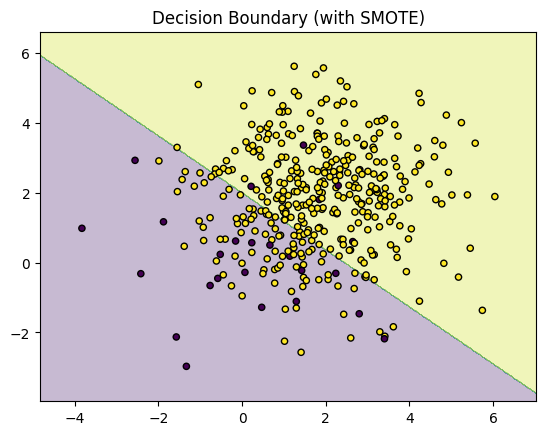

In [ ]:
# plot decision boundary for SMOTE data
plot_decision_boundaries_smote(X, y, classifier_smote)

# Balanced Random Forest

In [ ]:
# Import BalancedRandomForestClassifier and split data
from imblearn.ensemble import BalancedRandomForestClassifier


# split dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
# Initialize and train a BalancedRandomForestClassifier
classifier = BalancedRandomForestClassifier(random_state=42)
classifier.fit(X_train, y_train)

BalancedRandomForestClassifier(random_state=42)

In [ ]:
# Predict test set and print classification report for Balanced Random Forest
y_pred_brf = classifier.predict(X_test)
y_proba_brf = classifier.predict_proba(X_test)[:, 1]

# print classification report for SMOTE data
print('Classification Report (with SMOTE):')
print(classification_report(y_test, y_pred_brf))

Classification Report (with SMOTE):
              precision    recall  f1-score   support

           0       0.13      0.50      0.21         4
           1       0.97      0.83      0.89        76

    accuracy                           0.81        80
   macro avg       0.55      0.66      0.55        80
weighted avg       0.93      0.81      0.86        80



In [ ]:
# Print ROC AUC Score for Balanced Random Forest
print('ROC AUC Score (with SMOTE):', roc_auc_score(y_test, y_proba_brf))

ROC AUC Score (with SMOTE): 0.8273026315789473


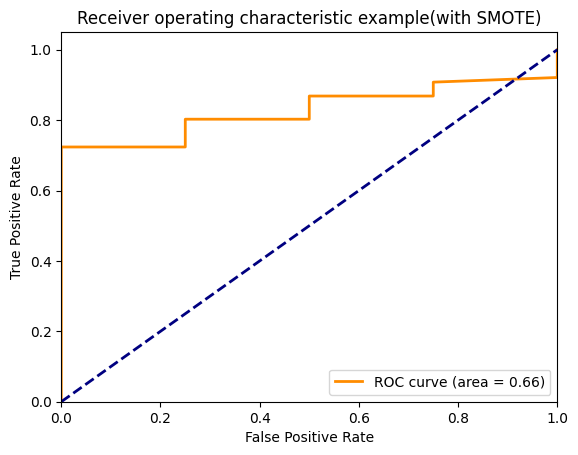

In [ ]:
# Plotting ROC AUC Curve for Balanced Random Forest
fpr_brf, tpr_brf, _ = roc_curve(y_test, y_proba_brf)
plt.figure()
plt.plot(fpr_brf, tpr_brf, color='darkorange', lw=2, label= 'ROC curve (area = %0.2f)' % roc_auc_score(y_test, y_pred_brf))
plt.plot([0,1], [0,1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver operating characteristic example(with SMOTE)')
plt.legend(loc="lower right")
plt.show()

In [ ]:
# Function to plot decision boundaries for Balanced Random Forest
def plot_decision_boundaries_smote(X, y, model):
  plot_step = 0.02
  x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
  y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
  xx, yy = np.meshgrid(np.arange(x_min, x_max, plot_step), np.arange(y_min, y_max, plot_step))
  Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
  Z = Z.reshape(xx.shape)
  plt.contourf(xx, yy, Z, alpha=0.3)
  plt.scatter(X[:, 0], X[:, 1], c=y, edgecolors='k', s =20)
  plt.title('Decision Boundary (with SMOTE)')
  plt.show()

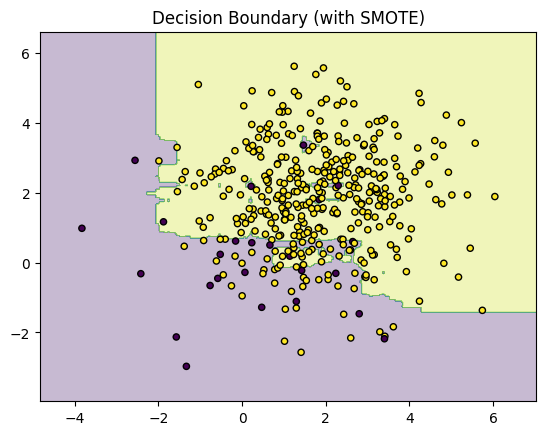

In [ ]:
# Plot decision boundary for Balanced Random Forest
plot_decision_boundaries_smote(X, y, classifier)

# Class Weights

In [ ]:
# Create and train a Logistic Regression model with class weights
# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Create a Logistic regresssion model with class weights
model = LogisticRegression(class_weight = {0:50,1:1}, solver='liblinear')

# Train the model
model.fit(X_train, y_train)

LogisticRegression(class_weight={0: 50, 1: 1}, solver='liblinear')

In [ ]:
# Predict the test set
y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:, 1]

# Print classification report
print('Classification Report:')
print(classification_report(y_test, y_pred))

Classification Report:
              precision    recall  f1-score   support

           0       0.08      1.00      0.15         4
           1       1.00      0.38      0.55        76

    accuracy                           0.41        80
   macro avg       0.54      0.69      0.35        80
weighted avg       0.95      0.41      0.53        80



ROC AUC Score: 0.9473684210526316


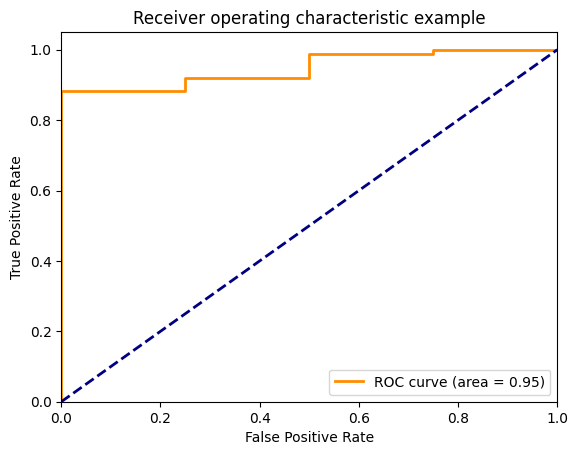

In [ ]:
# print ROC AUC Score
print('ROC AUC Score:', roc_auc_score(y_test, y_proba))

# Plotting ROC AUC Curve
fpr,tpr,_ = roc_curve(y_test, y_proba)
plt.figure()
plt.plot(fpr, tpr, color='darkorange', lw=2, label= 'ROC curve (area = %0.2f)' % roc_auc_score(y_test, y_proba))
plt.plot([0,1],[0,1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver operating characteristic example')
plt.legend(loc="lower right")
plt.show()

In [ ]:
# Function to plot decision boundaries
def plot_decision_boundaries(X, y, model):
  plot_step = 0.02
  x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
  y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
  xx, yy = np.meshgrid(np.arange(x_min, x_max, plot_step), np.arange(y_min, y_max, plot_step))
  z = model.predict(np.c_[xx.ravel(), yy.ravel()])
  z = z.reshape(xx.shape)
  plt.contourf(xx, yy, z, alpha=0.3)
  plt.scatter(X[:, 0], X[:, 1], c=y, edgecolors='k', s =20)
  plt.title('Decision Boundary')
  plt.show()

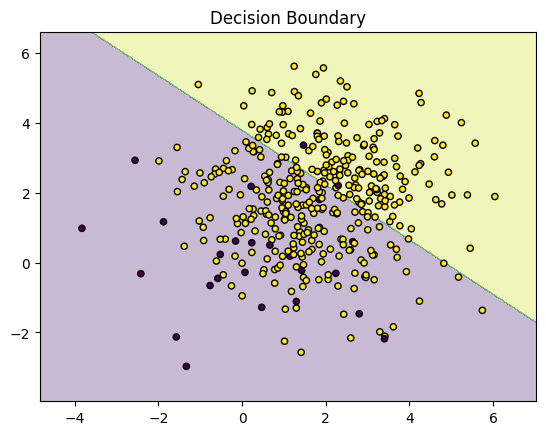

In [ ]:
# plot decision boundary
plot_decision_boundaries(X, y, model)

# Custom Loss Function

In [ ]:
# Import necessary libraries for custom loss function
import numpy as np
import xgboost as xgb
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from sklearn.metrics import classification_report, roc_auc_score, roc_curve
from sklearn.model_selection import train_test_split

In [ ]:
# Generate imbalanced dataset
n_samples_1 = 25
n_samples_2 = 375
centers = [(0,0), (2,2)]
cluster_std = [1.5,1.5]

X, y = make_blobs(n_samples=[n_samples_1, n_samples_2], centers=centers, cluster_std=cluster_std, random_state=0)

In [ ]:
# Split dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [ ]:
# Define a custom loss function for XGBoost
def custom_loss(preds, dtrain):
  labels = dtrain.get_label()
  pred = 1.0 / (1.0 + np.exp(-preds))

  # Define penalties
  false_positive_penalty = 10
  false_negative_penalty = 1.0

  grad = (pred - labels) * ((labels == 1) * false_negative_penalty + (labels == 0) * false_positive_penalty)
  hess = pred * (1 - pred) * ((labels == 1) * false_negative_penalty + (labels == 0) * false_positive_penalty)
  return grad, hess

In [ ]:
# Convert data to DMatrix format for XGBoost
dtrain = xgb.DMatrix(X_train, label=y_train)
dtest = xgb.DMatrix(X_test, label=y_test)

In [ ]:
# Set up parameters
params = {
    'max_depth': 3,
    'eta': 0.1,
}

In [ ]:
# Train up Parameters
bst = xgb.train(params, dtrain, num_boost_round=10, obj=custom_loss)

In [ ]:
# Predict test set
y_pred = np.where(bst.predict(dtest) > 0.5, 1, 0)
y_proba = bst.predict(dtest)

In [ ]:
# print classification report
print('Classification Report:')
print(classification_report(y_test, y_pred))

Classification Report:
              precision    recall  f1-score   support

           0       0.17      0.57      0.27         7
           1       0.97      0.83      0.90       113

    accuracy                           0.82       120
   macro avg       0.57      0.70      0.58       120
weighted avg       0.92      0.82      0.86       120



In [ ]:
# print ROC AUC Score
auc_score = roc_auc_score(y_test, y_proba)
print('ROC AUC Score:', auc_score)


ROC AUC Score: 0.7319848293299621


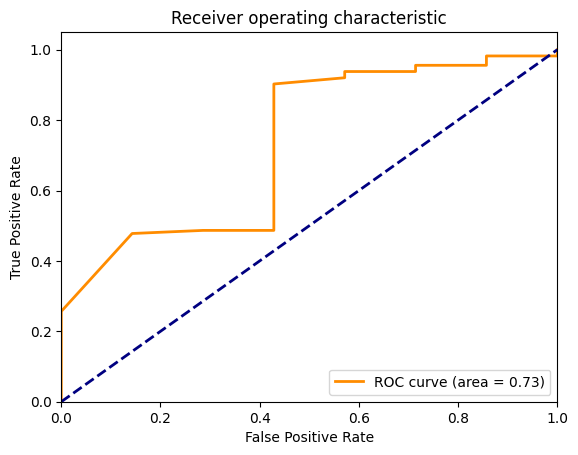

In [ ]:
# Plotting ROC AUC Curve
fpr, tpr, _ = roc_curve(y_test, y_proba)
plt.figure()
plt.plot(fpr, tpr, color='darkorange', lw=2, label= 'ROC curve (area = %0.2f)' % auc_score)
plt.plot([0,1], [0,1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver operating characteristic')
plt.legend(loc="lower right")
plt.show()

In [ ]:
# Define a function to plot decision boundaries for XGBoost model
def plot_decision_boundaries(X, y, model):
  plot_step = 0.02
  x_min, x_max = X[:, 0].min() -1, X[:, 0].max() +1
  y_min, y_max = X[:, 1].min() -1, X[:, 1].max() +1
  xx, yy = np.meshgrid(np.arange(x_min, x_max, plot_step), np.arange(y_min, y_max, plot_step))
  z = model.predict(xgb.DMatrix(np.c_[xx.ravel(), yy.ravel()]))
  z = np.where(z > 0.5, 1,0).reshape(xx.shape)
  plt.contourf(xx, yy, z, alpha=0.3)
  plt.scatter(X[:, 0], X[:, 1], c=y, edgecolors='k', s =20)
  plt.title('Decision Boundary')
  plt.show()

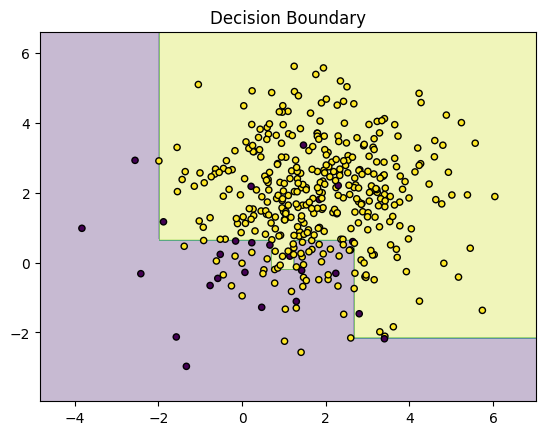

In [ ]:
# Plot decision boundary
plot_decision_boundaries(X, y, bst)
#

In [ ]:
# Calculate predicted probabilities from raw predictions
p = 1.0 / (1.0 + np.exp(-y_pred))